In [34]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random


np.random.seed(42)
random.seed(42)

# -----------------------------
# 1. 基础配置
# -----------------------------
n_rows = 20000

date_range = pd.date_range("2025-01-01", "2025-03-31", freq="D")

platforms = ["巨量引擎", "腾讯广告", "磁力引擎"]
channels = ["信息流", "搜索", "短视频", "开屏"]
creative_types = ["图文", "短视频", "直播切片"]
target_audiences = ["新客", "老客", "女性18-24", "男性25-34", "一线城市白领", "学生党"]
regions = ["华东", "华南", "华北", "华中", "西南"]
devices = ["iOS", "Android"]

campaign_names = [f"广告计划_{i:03d}" for i in range(1, 51)]
ad_groups = [f"广告组_{i:03d}" for i in range(1, 101)]

# -----------------------------
# 2. 业务规律配置
# -----------------------------
platform_impression_factor = {
    "巨量引擎": 1.30,
    "腾讯广告": 1.00,
    "磁力引擎": 0.85
}

platform_ctr_factor = {
    "巨量引擎": 0.95,
    "腾讯广告": 1.15,
    "磁力引擎": 1.00
}

channel_ctr_factor = {
    "信息流": 1.00,
    "搜索": 1.35,
    "短视频": 1.15,
    "开屏": 0.85
}

creative_cvr_factor = {
    "图文": 0.90,
    "短视频": 1.20,
    "直播切片": 1.10
}

audience_cvr_factor = {
    "新客": 0.85,
    "老客": 1.35,
    "女性18-24": 1.10,
    "男性25-34": 1.00,
    "一线城市白领": 1.15,
    "学生党": 0.95
}

platform_cvr_factor = {
    "巨量引擎": 1.05,
    "腾讯广告": 1.00,
    "磁力引擎": 0.90
}

platform_cpc_factor = {
    "巨量引擎": 1.00,
    "腾讯广告": 1.20,
    "磁力引擎": 0.90
}

audience_roi_factor = {
    "新客": 0.90,
    "老客": 1.25,
    "女性18-24": 1.10,
    "男性25-34": 1.00,
    "一线城市白领": 1.15,
    "学生党": 0.92
}

platform_roi_factor = {
    "巨量引擎": 1.10,
    "腾讯广告": 0.95,
    "磁力引擎": 0.90
}

# 设置几天异常波动，方便后面做异常分析
abnormal_days_low_ctr = {
    pd.Timestamp("2025-02-14"),
    pd.Timestamp("2025-03-08")
}

abnormal_days_high_cost = {
    pd.Timestamp("2025-02-20"),
    pd.Timestamp("2025-03-15")
}

# -----------------------------
# 3. 生成数据
# -----------------------------
rows = []

for _ in range(n_rows):
    date = random.choice(date_range)
    platform = random.choice(platforms)
    channel = random.choice(channels)
    creative_type = random.choice(creative_types)
    audience = random.choice(target_audiences)
    region = random.choice(regions)
    device = random.choice(devices)
    campaign_name = random.choice(campaign_names)
    ad_group = random.choice(ad_groups)

    # 曝光：受平台影响明显
    base_impressions = np.random.randint(800, 5000)
    impressions = int(base_impressions * platform_impression_factor[platform])


    #CTR基础值
    base_ctr = np.random.uniform(0.015, 0.08)
    ctr = base_ctr * channel_ctr_factor[channel] * platform_ctr_factor[platform]

    if date in abnormal_days_low_ctr:
        ctr *= 0.65

    ctr = min(max(ctr, 0.005), 0.20)
    clicks = int(impressions * ctr)


    # 某些日期故意让 CTR 下降
    if date in abnormal_days_low_ctr:
        ctr *= 0.65

    ctr = min(max(ctr, 0.005), 0.20)

    clicks = int(impressions * ctr)
    # CVR 基础值
    base_cvr = np.random.uniform(0.02, 0.18)
    cvr = (
    base_cvr
    * creative_cvr_factor[creative_type]
    * audience_cvr_factor[audience]
    * platform_cvr_factor[platform]
    )
    cvr = min(max(cvr, 0.005), 0.40)

    conversions = int(clicks * cvr)
    # CPC 基础
    base_cpc = np.random.uniform(0.8, 8.0)

    # 搜索流量通常更贵
    if channel == "搜索":
        base_cpc *= 1.25
    elif channel == "短视频":
        base_cpc *= 1.10

    # iOS 成本略高
    if device == "iOS":
        base_cpc *= 1.08

    base_cpc *= platform_cpc_factor[platform]

    cost = clicks * base_cpc

    # 某些日期故意让成本偏高
    if date in abnormal_days_high_cost:
        cost *= 1.35

    # 每个转化产生收入
    revenue_per_conversion = (
        np.random.uniform(20, 120)
        * audience_roi_factor[audience]
        * platform_roi_factor[platform]
    )

    revenue = conversions * revenue_per_conversion

    rows.append([
        date,
        platform,
        channel,
        campaign_name,
        ad_group,
        creative_type,
        audience,
        region,
        device,
        impressions,
        clicks,
        conversions,
        round(cost, 2),
        round(revenue, 2)
    ])

df = pd.DataFrame(rows, columns=[
    "date",
    "platform",
    "channel",
    "campaign_name",
    "ad_group",
    "creative_type",
    "target_audience",
    "region",
    "device",
    "impressions",
    "clicks",
    "conversions",
    "cost",
    "revenue"
])

# -----------------------------
# 4. 衍生指标
# -----------------------------
df["ctr"] = (df["clicks"] / df["impressions"]).round(4)
df["cvr"] = np.where(df["clicks"] > 0, (df["conversions"] / df["clicks"]).round(4), 0)
df["cpc"] = np.where(df["clicks"] > 0, (df["cost"] / df["clicks"]).round(2), 0)
df["cpa"] = np.where(df["conversions"] > 0, (df["cost"] / df["conversions"]).round(2), 0)
df["roi"] = np.where(df["cost"] > 0, (df["revenue"] / df["cost"]).round(2), 0)

# -----------------------------
# 5. 查看数据
# -----------------------------
print(df.shape)
df.head()

(20000, 19)


,date,platform,channel,campaign_name,ad_group,creative_type,target_audience,region,device,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,2025-03-23,巨量引擎,信息流,广告计划_009,广告组_095,直播切片,女性18-24,华南,iOS,2158,55,10,302.78,781.46,0.0255,0.1818,5.51,30.28,2.58
1,2025-01-14,磁力引擎,信息流,广告计划_006,广告组_028,直播切片,男性25-34,华东,iOS,3607,195,25,179.72,2632.30,0.0541,0.1282,0.92,7.19,14.65
2,2025-01-30,磁力引擎,信息流,广告计划_015,广告组_058,直播切片,老客,西南,Android,2748,73,4,196.48,326.14,0.0266,0.0548,2.69,49.12,1.66
3,2025-03-17,腾讯广告,信息流,广告计划_018,广告组_020,图文,学生党,华中,Android,3704,144,14,311.79,602.19,0.0389,0.0972,2.17,22.27,1.93
4,2025-01-28,腾讯广告,信息流,广告计划_023,广告组_078,图文,男性25-34,华东,Android,1775,61,1,384.47,55.33,0.0344,0.0164,6.30,384.47,0.14


In [35]:
df.to_csv("../data/raw/ad_data_raw.csv", index=False)
print("已保存到 ../data/raw/ad_data_raw.csv")

已保存到 ../data/raw/ad_data_raw.csv


In [36]:
print(df.describe())
print(df["platform"].value_counts())
print(df["channel"].value_counts())
print(df[["ctr", "cvr", "cpc", "cpa", "roi"]].describe())

                             date  impressions        clicks   conversions  \
count                       20000  20000.00000  20000.000000  20000.000000   
mean   2025-02-14 15:57:18.720000   3033.71770    157.912450     17.300950   
min           2025-01-01 00:00:00    680.00000      4.000000      0.000000   
25%           2025-01-23 00:00:00   1861.75000     77.000000      6.000000   
50%           2025-02-15 00:00:00   2940.00000    132.000000     12.000000   
75%           2025-03-09 00:00:00   4019.00000    216.000000     23.000000   
max           2025-03-31 00:00:00   6498.00000    652.000000    153.000000   
std                           NaN   1401.86971    105.457541     16.461134   

               cost       revenue           ctr           cvr           cpc  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean     840.099433   1299.631609      0.052284      0.106193      5.186602   
min        7.320000      0.000000      0.004800      0.00000

## 3. 数据检查与清洗

In [37]:
# 查看基本信息
print(df.shape)
print(df.columns)
df.info()

(20000, 19)
Index(['date', 'platform', 'channel', 'campaign_name', 'ad_group',
       'creative_type', 'target_audience', 'region', 'device', 'impressions',
       'clicks', 'conversions', 'cost', 'revenue', 'ctr', 'cvr', 'cpc', 'cpa',
       'roi'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             20000 non-null  datetime64[us]
 1   platform         20000 non-null  str           
 2   channel          20000 non-null  str           
 3   campaign_name    20000 non-null  str           
 4   ad_group         20000 non-null  str           
 5   creative_type    20000 non-null  str           
 6   target_audience  20000 non-null  str           
 7   region           20000 non-null  str           
 8   device           20000 non-null  str           
 9   impressions      20000 non-null  int64      

In [38]:
# 缺失值检查
print(df.isnull().sum())

# 重复值检查
print("重复行数量：", df.duplicated().sum())

date               0
platform           0
channel            0
campaign_name      0
ad_group           0
creative_type      0
target_audience    0
region             0
device             0
impressions        0
clicks             0
conversions        0
cost               0
revenue            0
ctr                0
cvr                0
cpc                0
cpa                0
roi                0
dtype: int64
重复行数量： 0


In [39]:
df[["impressions", "clicks", "conversions", "cost", "revenue", "ctr", "cvr", "cpc", "cpa", "roi"]].describe()

,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,3033.71770,157.912450,17.300950,840.099433,1299.631609,0.052284,0.106193,5.186602,71.383147,2.189303
std,1401.86971,105.457541,16.461134,798.561565,1540.343732,0.023949,0.057412,2.630657,73.899090,2.650238
min,680.00000,4.000000,0.000000,7.320000,0.000000,0.004800,0.000000,0.720000,0.000000,0.000000
25%,1861.75000,77.000000,6.000000,286.945000,339.812500,0.032400,0.059300,2.970000,27.290000,0.650000
50%,2940.00000,132.000000,12.000000,586.940000,783.480000,0.050200,0.101900,5.080000,48.810000,1.330000
75%,4019.00000,216.000000,23.000000,1122.630000,1646.157500,0.069100,0.146000,7.140000,85.820000,2.640000
max,6498.00000,652.000000,153.000000,6855.520000,22873.570000,0.124100,0.302000,16.560000,1219.580000,46.440000


In [40]:
df[["impressions", "clicks", "conversions", "cost", "revenue", "ctr", "cvr", "cpc", "cpa", "roi"]].describe()

,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
count,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,3033.71770,157.912450,17.300950,840.099433,1299.631609,0.052284,0.106193,5.186602,71.383147,2.189303
std,1401.86971,105.457541,16.461134,798.561565,1540.343732,0.023949,0.057412,2.630657,73.899090,2.650238
min,680.00000,4.000000,0.000000,7.320000,0.000000,0.004800,0.000000,0.720000,0.000000,0.000000
25%,1861.75000,77.000000,6.000000,286.945000,339.812500,0.032400,0.059300,2.970000,27.290000,0.650000
50%,2940.00000,132.000000,12.000000,586.940000,783.480000,0.050200,0.101900,5.080000,48.810000,1.330000
75%,4019.00000,216.000000,23.000000,1122.630000,1646.157500,0.069100,0.146000,7.140000,85.820000,2.640000
max,6498.00000,652.000000,153.000000,6855.520000,22873.570000,0.124100,0.302000,16.560000,1219.580000,46.440000


In [41]:
# 点击不能大于曝光
print("clicks > impressions:", (df["clicks"] > df["impressions"]).sum())

# 转化不能大于点击
print("conversions > clicks:", (df["conversions"] > df["clicks"]).sum())

# 成本和收入不能为负
print("cost < 0:", (df["cost"] < 0).sum())
print("revenue < 0:", (df["revenue"] < 0).sum())

clicks > impressions: 0
conversions > clicks: 0
cost < 0: 0
revenue < 0: 0


In [42]:
df_clean = df.copy()

# 去重
df_clean = df_clean.drop_duplicates()

# 日期格式处理
df_clean["date"] = pd.to_datetime(df_clean["date"])

# 数值列类型检查
numeric_cols = ["impressions", "clicks", "conversions", "cost", "revenue", "ctr", "cvr", "cpc", "cpa", "roi"]
df_clean[numeric_cols] = df_clean[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 再次检查缺失
print(df_clean.isnull().sum())
print(df_clean.shape)

date               0
platform           0
channel            0
campaign_name      0
ad_group           0
creative_type      0
target_audience    0
region             0
device             0
impressions        0
clicks             0
conversions        0
cost               0
revenue            0
ctr                0
cvr                0
cpc                0
cpa                0
roi                0
dtype: int64
(20000, 19)


In [43]:
df_clean.to_csv("../data/clean/ad_data_clean.csv", index=False)
print("已保存到 ../data/clean/ad_data_clean.csv")

已保存到 ../data/clean/ad_data_clean.csv


## 4. 平台投放效果分析

In [44]:
platform_summary = df_clean.groupby("platform").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

platform_summary["ctr"] = platform_summary["clicks"] / platform_summary["impressions"]
platform_summary["cvr"] = platform_summary["conversions"] / platform_summary["clicks"]
platform_summary["cpc"] = platform_summary["cost"] / platform_summary["clicks"]
platform_summary["cpa"] = platform_summary["cost"] / platform_summary["conversions"]
platform_summary["roi"] = platform_summary["revenue"] / platform_summary["cost"]

platform_summary = platform_summary.round(4)
platform_summary

,platform,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,巨量引擎,24800954,1190845,138823,6069913.27,11384343.38,0.0480,0.1166,5.0971,43.7241,1.8755
1,磁力引擎,16241508,819870,80357,3751417.48,5500714.88,0.0505,0.0980,4.5756,46.6844,1.4663
2,腾讯广告,19631892,1147534,126839,6980657.91,9107573.93,0.0585,0.1105,6.0832,55.0356,1.3047


In [45]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.sans-serif"] = ["Noto Sans CJK SC", "SimHei", "Microsoft YaHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 24040 (\N{CJK UNIFIED IDEOGRAPH-5DE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 25806 (\N{CJK UNIFIED IDEOGRAPH-64CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following 

/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 30913 (\N{CJK UNIFIED IDEOGRAPH-78C1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 33150 (\N{CJK UNIFIED IDEOGRAPH-817E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 35759 (\N{CJK UNIFIED IDEOGRAPH-8BAF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2703003316.py:7: UserWarning: Glyph 21578 (\N{CJK UNIFIED IDEOGRA

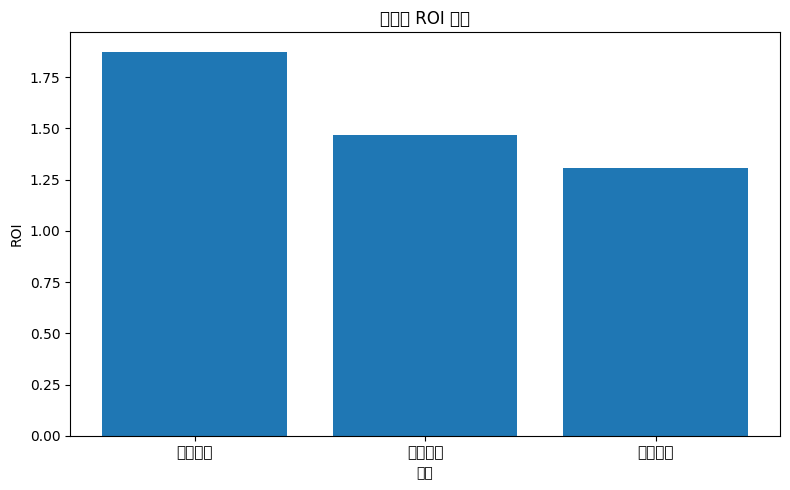

In [46]:
plt.figure(figsize=(8, 5))
plt.bar(platform_summary["platform"], platform_summary["roi"])
plt.title("各平台 ROI 对比")
plt.xlabel("平台")
plt.ylabel("ROI")
plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig("../figures/platform_roi.png", dpi=300, bbox_inches="tight")
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/2153255061.py:7: UserWarning: Glyph 24040 (\N{CJK UNIFIED IDEOGRAPH-5DE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2153255061.py:7: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2153255061.py:7: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2153255061.py:7: UserWarning: Glyph 25806 (\N{CJK UNIFIED IDEOGRAPH-64CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following 

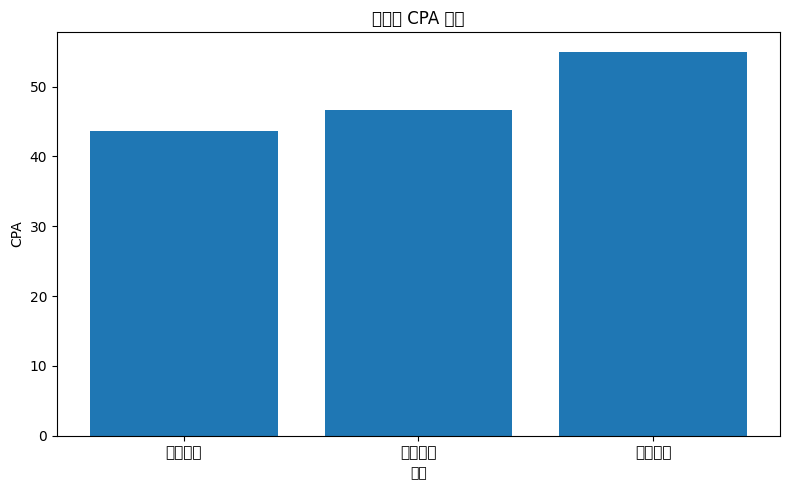

In [47]:
plt.figure(figsize=(8, 5))
plt.bar(platform_summary["platform"], platform_summary["cpa"])
plt.title("各平台 CPA 对比")
plt.xlabel("平台")
plt.ylabel("CPA")
plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig("../figures/platform_cpa.png", dpi=300, bbox_inches="tight")
plt.show()

### 平台投放效果分析结论
从平台维度看，不同广告平台在流量规模、成本控制和收益表现上存在明显差异。

- 巨量引擎曝光规模最大，ROI 最高，CPA 最低，说明该平台在当前样本下兼具放量能力和转化效率；
- 腾讯广告 CTR 最高，说明点击吸引能力较强，但其 CPA 最高、ROI 最低，说明点击质量和转化效率相对偏弱；
- 磁力引擎整体表现居中，在成本与收益之间呈现相对平衡的状态。

这表明广告投放分析不能只关注曝光和点击规模，还需要结合 CPA、ROI 等指标综合评估平台投放效果。

## 5. 高消耗低转化广告计划识别

In [48]:
campaign_summary = df_clean.groupby("campaign_name").agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

campaign_summary["ctr"] = campaign_summary["clicks"] / campaign_summary["impressions"]
campaign_summary["cvr"] = campaign_summary["conversions"] / campaign_summary["clicks"]
campaign_summary["cpc"] = campaign_summary["cost"] / campaign_summary["clicks"]
campaign_summary["cpa"] = campaign_summary["cost"] / campaign_summary["conversions"]
campaign_summary["roi"] = campaign_summary["revenue"] / campaign_summary["cost"]

campaign_summary = campaign_summary.round(4)
campaign_summary.head()

,campaign_name,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,广告计划_001,1191881,62880,6599,353163.58,496409.83,0.0528,0.1049,5.6165,53.5177,1.4056
1,广告计划_002,1155039,59888,6875,301491.25,507834.03,0.0518,0.1148,5.0343,43.8533,1.6844
2,广告计划_003,1229590,65697,6798,351730.04,508132.92,0.0534,0.1035,5.3538,51.7402,1.4447
3,广告计划_004,1282119,67275,7529,378192.23,575064.05,0.0525,0.1119,5.6216,50.2314,1.5206
4,广告计划_005,1178537,59275,6450,323051.70,486918.96,0.0503,0.1088,5.4500,50.0855,1.5072


In [49]:
cost_threshold = campaign_summary["cost"].quantile(0.75)
roi_threshold = campaign_summary["roi"].quantile(0.25)

problem_campaigns = campaign_summary[
    (campaign_summary["cost"] >= cost_threshold) &
    (campaign_summary["roi"] <= roi_threshold)
].copy()

problem_campaigns = problem_campaigns.sort_values(by="cost", ascending=False)

print("高消耗阈值:", round(cost_threshold, 2))
print("低ROI阈值:", round(roi_threshold, 4))
print("问题计划数量:", problem_campaigns.shape[0])

problem_campaigns.head(10)

高消耗阈值: 353408.65
低ROI阈值: 1.501
问题计划数量: 3


,campaign_name,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
34,广告计划_035,1318005,67271,7182,375478.69,562964.86,0.0510,0.1068,5.5816,52.2805,1.4993
28,广告计划_029,1254567,66901,7099,356869.01,514972.05,0.0533,0.1061,5.3343,50.2703,1.4430
13,广告计划_014,1215857,64478,6858,354171.35,496570.59,0.0530,0.1064,5.4929,51.6435,1.4021


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/2416492660.py:11: UserWarning: Glyph 24191 (\N{CJK UNIFIED IDEOGRAPH-5E7F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2416492660.py:11: UserWarning: Glyph 21578 (\N{CJK UNIFIED IDEOGRAPH-544A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2416492660.py:11: UserWarning: Glyph 35745 (\N{CJK UNIFIED IDEOGRAPH-8BA1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2416492660.py:11: UserWarning: Glyph 21010 (\N{CJK UNIFIED IDEOGRAPH-5212}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the follow

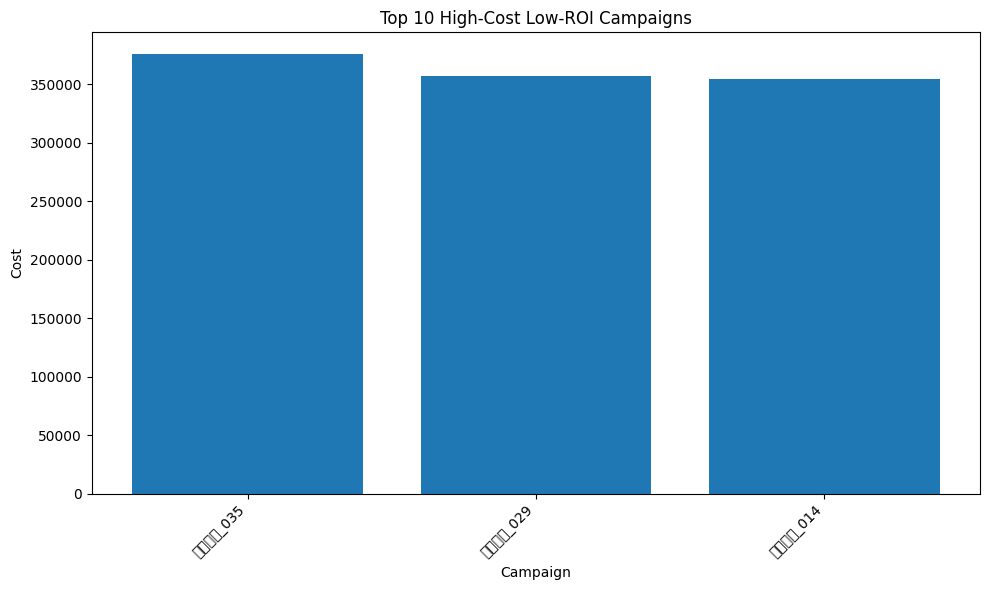

In [50]:
import matplotlib.pyplot as plt

top_problem_campaigns = problem_campaigns.head(10).copy()

plt.figure(figsize=(10, 6))
plt.bar(top_problem_campaigns["campaign_name"], top_problem_campaigns["cost"])
plt.title("Top 10 High-Cost Low-ROI Campaigns")
plt.xlabel("Campaign")
plt.ylabel("Cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../figures/high_cost_low_roi_campaigns.png", dpi=300, bbox_inches="tight")
plt.show()

In [51]:
problem_campaigns[["campaign_name", "cost", "conversions", "ctr", "cvr", "cpa", "roi"]].head(10)

,campaign_name,cost,conversions,ctr,cvr,cpa,roi
34,广告计划_035,375478.69,7182,0.0510,0.1068,52.2805,1.4993
28,广告计划_029,356869.01,7099,0.0533,0.1061,50.2703,1.4430
13,广告计划_014,354171.35,6858,0.0530,0.1064,51.6435,1.4021


In [52]:
problem_campaigns_analysis = problem_campaigns[
    ["campaign_name", "cost", "conversions", "ctr", "cvr", "cpa", "roi"]
].sort_values(by=["cost", "roi"], ascending=[False, True])

problem_campaigns_analysis.head(10)

,campaign_name,cost,conversions,ctr,cvr,cpa,roi
34,广告计划_035,375478.69,7182,0.0510,0.1068,52.2805,1.4993
28,广告计划_029,356869.01,7099,0.0533,0.1061,50.2703,1.4430
13,广告计划_014,354171.35,6858,0.0530,0.1064,51.6435,1.4021


### 高消耗低转化广告计划识别结论
基于广告计划维度的汇总结果，进一步以“高消耗且低 ROI”作为筛选标准，对问题广告计划进行识别。

分析结果表明，部分广告计划虽然消耗较高，但转化效率偏低、ROI 表现较差，属于典型的高消耗低转化计划。这类计划可能存在以下问题：

- 素材吸引力不足，导致点击后转化效率偏低；
- 人群定向不够精准，带来较高成本但未形成有效转化；
- 投放渠道或平台与目标人群匹配度较低；
- 预算分配不合理，导致低效计划持续消耗成本。

在实际投放中，这类广告计划应重点监控，并结合素材、人群和渠道维度进一步排查原因，作为预算调整和投放优化的重要依据。

In [53]:
campaign_platform_summary = df_clean.groupby(["campaign_name", "platform"]).agg(
    impressions=("impressions", "sum"),
    clicks=("clicks", "sum"),
    conversions=("conversions", "sum"),
    cost=("cost", "sum"),
    revenue=("revenue", "sum")
).reset_index()

campaign_platform_summary["ctr"] = campaign_platform_summary["clicks"] / campaign_platform_summary["impressions"]
campaign_platform_summary["cvr"] = campaign_platform_summary["conversions"] / campaign_platform_summary["clicks"]
campaign_platform_summary["cpa"] = campaign_platform_summary["cost"] / campaign_platform_summary["conversions"]
campaign_platform_summary["roi"] = campaign_platform_summary["revenue"] / campaign_platform_summary["cost"]

campaign_platform_summary = campaign_platform_summary.round(4)

problem_campaign_names = problem_campaigns["campaign_name"].tolist()

problem_campaign_platforms = campaign_platform_summary[
    campaign_platform_summary["campaign_name"].isin(problem_campaign_names)
]

problem_campaign_platforms.head(10)

,campaign_name,platform,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpa,roi
39,广告计划_014,巨量引擎,484030,23835,2623,124606.01,215240.00,0.0492,0.1100,47.5052,1.7274
40,广告计划_014,磁力引擎,312339,16470,1612,76723.50,114726.29,0.0527,0.0979,47.5952,1.4953
41,广告计划_014,腾讯广告,419488,24173,2623,152841.84,166604.30,0.0576,0.1085,58.2699,1.0900
84,广告计划_029,巨量引擎,536563,27062,2968,140563.88,230104.18,0.0504,0.1097,47.3598,1.6370
85,广告计划_029,磁力引擎,293616,15227,1393,70135.13,96063.60,0.0519,0.0915,50.3483,1.3697
86,广告计划_029,腾讯广告,424388,24612,2738,146170.00,188804.27,0.0580,0.1112,53.3857,1.2917
102,广告计划_035,巨量引擎,612894,28991,2983,159338.56,247959.84,0.0473,0.1029,53.4155,1.5562
103,广告计划_035,磁力引擎,273288,12805,1217,57629.36,83016.72,0.0469,0.0950,47.3536,1.4405
104,广告计划_035,腾讯广告,431823,25475,2982,158510.77,231988.30,0.0590,0.1171,53.1559,1.4635


In [54]:
problem_platform_dist = problem_campaign_platforms["platform"].value_counts()
print(problem_platform_dist)

platform
巨量引擎    3
磁力引擎    3
腾讯广告    3
Name: count, dtype: int64


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/395782419.py:6: UserWarning: Glyph 24040 (\N{CJK UNIFIED IDEOGRAPH-5DE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/395782419.py:6: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/395782419.py:6: UserWarning: Glyph 24341 (\N{CJK UNIFIED IDEOGRAPH-5F15}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/395782419.py:6: UserWarning: Glyph 25806 (\N{CJK UNIFIED IDEOGRAPH-64CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following fami

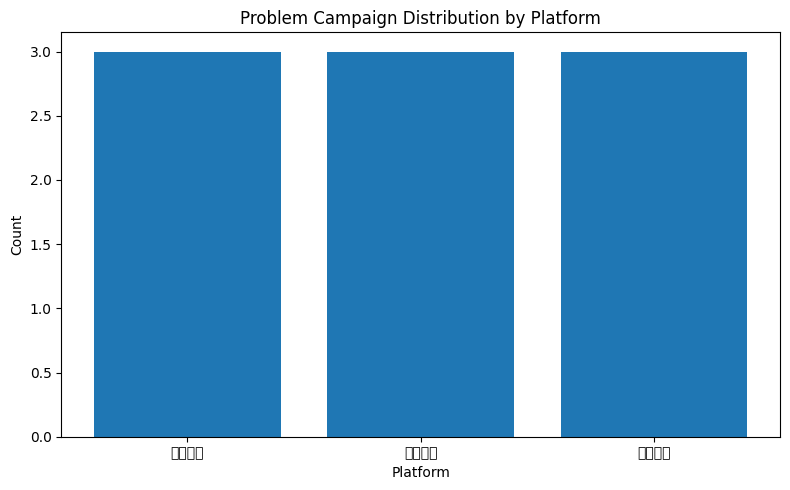

In [55]:
plt.figure(figsize=(8, 5))
plt.bar(problem_platform_dist.index, problem_platform_dist.values)
plt.title("Problem Campaign Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../figures/problem_campaign_platform_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

- 基于广告计划维度构建高消耗低转化识别逻辑，筛选问题计划并从平台、成本、转化效率等角度进行分析。

## 6. 不同素材类型转化效果分析

In [56]:
creative_summary = df_clean.groupby("creative_type").agg(
    impressions=("impressions","sum"),
    clicks=("clicks","sum"),
    conversions=("conversions","sum"),
    cost=("cost","sum")
).reset_index()

creative_summary["ctr"] = creative_summary["clicks"]/creative_summary["impressions"]
creative_summary["cvr"] = creative_summary["conversions"]/creative_summary["clicks"]
creative_summary["cpa"] = creative_summary["cost"]/creative_summary["conversions"]

creative_summary.round(4)

,creative_type,impressions,clicks,conversions,cost,ctr,cvr,cpa
0,图文,20520394,1053097,97516,5609484.47,0.0513,0.0926,57.5237
1,直播切片,20332847,1063551,119864,5649530.23,0.0523,0.1127,47.1328
2,短视频,19821113,1041601,128639,5542973.96,0.0526,0.1235,43.0894


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/3736050702.py:6: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/3736050702.py:6: UserWarning: Glyph 25991 (\N{CJK UNIFIED IDEOGRAPH-6587}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/3736050702.py:6: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/3736050702.py:6: UserWarning: Glyph 25773 (\N{CJK

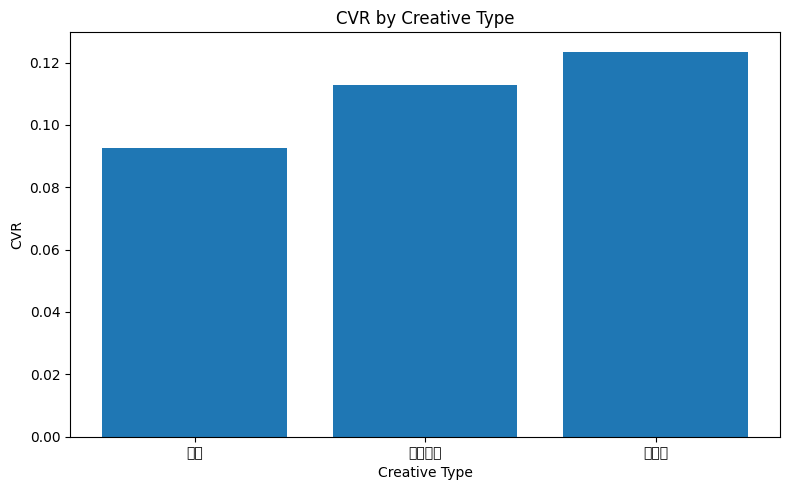

In [57]:
plt.figure(figsize=(8,5))
plt.bar(creative_summary["creative_type"], creative_summary["cvr"])
plt.title("CVR by Creative Type")
plt.xlabel("Creative Type")
plt.ylabel("CVR")
plt.tight_layout()
plt.savefig("../figures/cvr_by_creative.png", dpi=300)
plt.show()

## 7. 不同人群转化效果分析

In [58]:
audience_summary = df_clean.groupby("target_audience").agg(
    impressions=("impressions","sum"),
    clicks=("clicks","sum"),
    conversions=("conversions","sum"),
    cost=("cost","sum")
).reset_index()

audience_summary["ctr"] = audience_summary["clicks"]/audience_summary["impressions"]
audience_summary["cvr"] = audience_summary["conversions"]/audience_summary["clicks"]
audience_summary["cpa"] = audience_summary["cost"]/audience_summary["conversions"]

audience_summary.round(4)

,target_audience,impressions,clicks,conversions,cost,ctr,cvr,cpa
0,一线城市白领,10113762,521196,61953,2806995.47,0.0515,0.1189,45.3085
1,女性18-24,9965524,521772,59246,2777073.00,0.0524,0.1135,46.8736
2,学生党,10358525,544334,53048,2880339.19,0.0525,0.0975,54.2968
3,新客,10130252,526609,46143,2814732.70,0.0520,0.0876,61.0002
4,男性25-34,10143409,529460,54691,2817683.88,0.0522,0.1033,51.5201
5,老客,9962882,514878,70938,2705164.42,0.0517,0.1378,38.1342


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
/tmp/ipykernel_12915/2415937918.py:7: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2415937918.py:7: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2415937918.py:7: UserWarning: Glyph 22478 (\N{CJK UNIFIED IDEOGRAPH-57CE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2415937918.py:7: UserWarning: Glyph 24066 (\N{CJK UNIFIED IDEOGRAPH-5E02}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_12915/2415937918.py:7: UserWarning: Glyph 30333 (\N{CJK UNIFIED

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC, SimHei, Microsoft YaHei, Arial Unicode MS
findfont: Generic family 'sans-serif' not foun

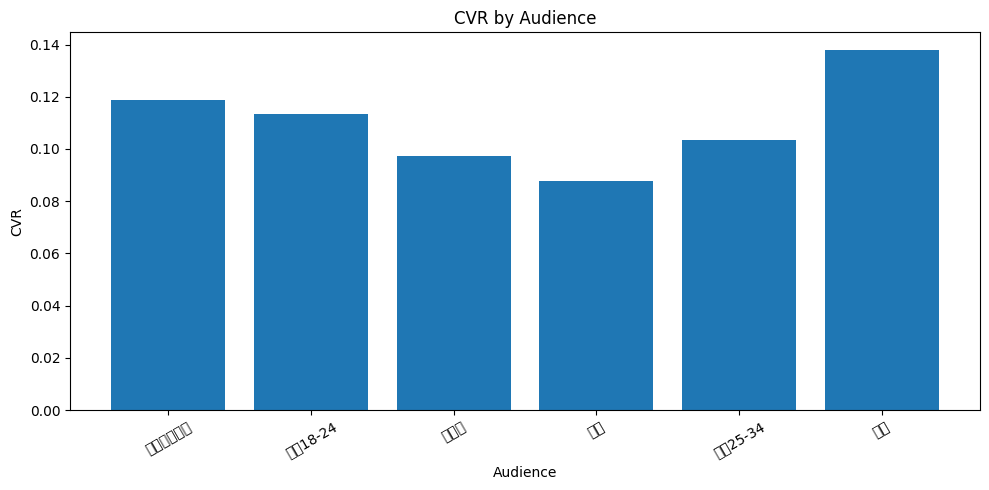

In [59]:
plt.figure(figsize=(10,5))
plt.bar(audience_summary["target_audience"], audience_summary["cvr"])
plt.title("CVR by Audience")
plt.xlabel("Audience")
plt.ylabel("CVR")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("../figures/cvr_by_audience.png", dpi=300)
plt.show()

## 8. SQL 分析验证(DuckDB)

In [60]:
import duckdb

con = duckdb.connect()

# 直接把清洗后的 CSV 注册成表
con.execute("""
    CREATE OR REPLACE TABLE ad_data AS
    SELECT * FROM read_csv_auto('../data/clean/ad_data_clean.csv');
""")

con.execute("SELECT COUNT(*) AS row_count FROM ad_data").df()


,row_count
0,20000


### 8.1平台效果分析

In [61]:
platform_sql = """
SELECT
    platform,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cpc,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa,
    ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(cost), 0), 4) AS roi
FROM ad_data
GROUP BY platform
ORDER BY roi DESC
"""

platform_sql_result = con.execute(platform_sql).df()
platform_sql_result

,platform,impressions,clicks,conversions,cost,revenue,ctr,cvr,cpc,cpa,roi
0,巨量引擎,24800954.0,1190845.0,138823.0,6069913.27,11384343.38,0.0480,0.1166,5.0971,43.7241,1.8755
1,磁力引擎,16241508.0,819870.0,80357.0,3751417.48,5500714.88,0.0505,0.0980,4.5756,46.6844,1.4663
2,腾讯广告,19631892.0,1147534.0,126839.0,6980657.91,9107573.93,0.0585,0.1105,6.0832,55.0356,1.3047


### 8.2素材效果分析

In [62]:
creative_sql = """
SELECT
    creative_type,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa
FROM ad_data
GROUP BY creative_type
ORDER BY cvr DESC
"""

creative_sql_result = con.execute(creative_sql).df()
creative_sql_result

,creative_type,impressions,clicks,conversions,cost,ctr,cvr,cpa
0,短视频,19821113.0,1041601.0,128639.0,5542973.96,0.0526,0.1235,43.0894
1,直播切片,20332847.0,1063551.0,119864.0,5649530.23,0.0523,0.1127,47.1328
2,图文,20520394.0,1053097.0,97516.0,5609484.47,0.0513,0.0926,57.5237


### 8.3人群效果分析

In [63]:
audience_sql = """
SELECT
    target_audience,
    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(conversions) AS conversions,
    ROUND(SUM(cost), 2) AS cost,
    ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
    ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
    ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa
FROM ad_data
GROUP BY target_audience
ORDER BY cvr DESC
"""

audience_sql_result = con.execute(audience_sql).df()
audience_sql_result

,target_audience,impressions,clicks,conversions,cost,ctr,cvr,cpa
0,老客,9962882.0,514878.0,70938.0,2705164.42,0.0517,0.1378,38.1342
1,一线城市白领,10113762.0,521196.0,61953.0,2806995.47,0.0515,0.1189,45.3085
2,女性18-24,9965524.0,521772.0,59246.0,2777073.00,0.0524,0.1135,46.8736
3,男性25-34,10143409.0,529460.0,54691.0,2817683.88,0.0522,0.1033,51.5201
4,学生党,10358525.0,544334.0,53048.0,2880339.19,0.0525,0.0975,54.2968
5,新客,10130252.0,526609.0,46143.0,2814732.70,0.0520,0.0876,61.0002


### 8.4高消耗低转化计划识别

In [64]:
problem_campaign_sql = """
WITH campaign_summary AS (
    SELECT
        campaign_name,
        ROUND(SUM(cost), 2) AS total_cost,
        SUM(conversions) AS total_conversions,
        ROUND(SUM(revenue), 2) AS total_revenue,
        ROUND(SUM(clicks) * 1.0 / NULLIF(SUM(impressions), 0), 4) AS ctr,
        ROUND(SUM(conversions) * 1.0 / NULLIF(SUM(clicks), 0), 4) AS cvr,
        ROUND(SUM(cost) * 1.0 / NULLIF(SUM(conversions), 0), 4) AS cpa,
        ROUND(SUM(revenue) * 1.0 / NULLIF(SUM(cost), 0), 4) AS roi
    FROM ad_data
    GROUP BY campaign_name
)
SELECT *
FROM campaign_summary
ORDER BY total_cost DESC, roi ASC
LIMIT 10
"""

problem_campaign_sql_result = con.execute(problem_campaign_sql).df()
problem_campaign_sql_result

,campaign_name,total_cost,total_conversions,total_revenue,ctr,cvr,cpa,roi
0,广告计划_006,399256.71,8180.0,635455.20,0.0553,0.1105,48.8089,1.5916
1,广告计划_004,378192.23,7529.0,575064.05,0.0525,0.1119,50.2314,1.5206
2,广告计划_008,377625.52,7620.0,573700.94,0.0540,0.1073,49.5572,1.5192
3,广告计划_035,375478.69,7182.0,562964.86,0.0510,0.1068,52.2805,1.4993
4,广告计划_017,363885.94,7746.0,579170.61,0.0521,0.1124,46.9773,1.5916
5,广告计划_037,363229.91,7859.0,607717.91,0.0519,0.1143,46.2183,1.6731
6,广告计划_033,358938.82,7302.0,549154.67,0.0506,0.1127,49.1562,1.5299
7,广告计划_050,358637.31,7166.0,540187.20,0.0525,0.1112,50.0471,1.5062
8,广告计划_036,357795.12,7098.0,552037.52,0.0511,0.1084,50.4079,1.5429
9,广告计划_044,356943.07,7402.0,538491.57,0.0539,0.1070,48.2225,1.5086
